# 🧠 Deep Learning - Partie 1: Le Perceptron

## 🎯 Objectifs
- Implémenter un perceptron simple from scratch
- Comprendre l'algorithme d'apprentissage
- Visualiser la frontière de décision
- Tester sur des problèmes linéairement séparables

---
*Session 05 - SupNum Nouakchott - Formation IA & Machine Learning*

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("🚀 Prêt à implémenter le perceptron!")

🚀 Prêt à implémenter le perceptron!


## 🔧 1. Implémentation du Perceptron

Le perceptron est le plus simple des réseaux de neurones.
Il peut résoudre des problèmes **linéairement séparables**.

In [10]:
class Perceptron:
    """Implémentation simple du perceptron"""
    
    def __init__(self, learning_rate=0.1, max_iter=100):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = None
        self.errors = []
    
    def fit(self, X, y):
        """Entraîne le perceptron"""
        n_samples, n_features = X.shape
        
        # Initialisation des poids et biais
        self.weights = np.random.normal(0, 0.01, n_features)
        self.bias = 0
        
        # Conversion des labels en -1, 1
        y_ = np.where(y <= 0, -1, 1)
        
        # Algorithme d'apprentissage
        for i in range(self.max_iter):
            errors = 0
            for idx, x_i in enumerate(X):
                # Prédiction
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = np.where(linear_output >= 0, 1, -1)
                
                # Mise à jour si erreur
                if y_[idx] != y_predicted:
                    self.weights += self.learning_rate * y_[idx] * x_i
                    self.bias += self.learning_rate * y_[idx]
                    errors += 1
            
            self.errors.append(errors)
            if errors == 0:
                break
        
        return self
    
    def predict(self, X):
        """Fait des prédictions"""
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)
    
    def decision_function(self, X):
        """Calcule la sortie linéaire"""
        return np.dot(X, self.weights) + self.bias

# Test du perceptron
print("✅ Classe Perceptron implémentée!")

✅ Classe Perceptron implémentée!


## 📊 2. Génération de données d'exemple

Créons des données linéairement séparables pour tester notre perceptron.

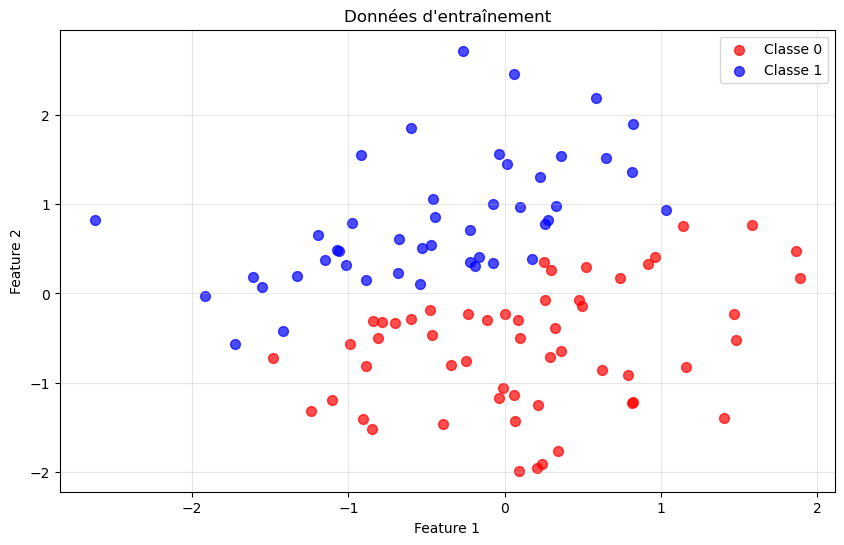

In [11]:
def generer_donnees_lineaires(n_samples=100, noise=0.1, random_state=42):
    """Génère des données linéairement séparables"""
    np.random.seed(random_state)
    
    # Génération de points
    X = np.random.randn(n_samples, 2)
    
    # Ligne de séparation: y = 0.5*x + 0.2
    y = (X[:, 1] > 0.5 * X[:, 0] + 0.2 + noise * np.random.randn(n_samples)).astype(int)
    
    return X, y

def visualiser_donnees(X, y, title="Données d'entraînement"):
    """Visualise les données"""
    plt.figure(figsize=(10, 6))
    
    colors = ['red', 'blue']
    labels = ['Classe 0', 'Classe 1']
    
    for i in range(2):
        mask = y == i
        plt.scatter(X[mask, 0], X[mask, 1], 
                   c=colors[i], label=labels[i], alpha=0.7, s=50)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Génération et visualisation
X, y = generer_donnees_lineaires()
visualiser_donnees(X, y)

## 🎯 3. Entraînement interactif du Perceptron

Testons différents paramètres d'apprentissage.

In [12]:
@interact(
    learning_rate=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='Taux d\'apprentissage:'),
    max_iter=IntSlider(min=10, max=200, step=10, value=100, description='Itérations max:'),
    noise=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.1, description='Bruit:')
)
def entrainement_interactif(learning_rate, max_iter, noise):
    """Interface interactive pour l'entraînement"""
    
    # Génération des données
    X, y = generer_donnees_lineaires(noise=noise)
    
    # Entraînement
    perceptron = Perceptron(learning_rate=learning_rate, max_iter=max_iter)
    perceptron.fit(X, y)
    
    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Graphique 1: Données et frontière de décision
    colors = ['red', 'blue']
    labels = ['Classe 0', 'Classe 1']
    
    for i in range(2):
        mask = y == i
        ax1.scatter(X[mask, 0], X[mask, 1], 
                   c=colors[i], label=labels[i], alpha=0.7, s=50)
    
    # Frontière de décision
    if perceptron.weights is not None:
        xlim = ax1.get_xlim()
        ylim = ax1.get_ylim()
        
        # Grille pour la frontière
        xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                            np.linspace(ylim[0], ylim[1], 100))
        
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        Z = perceptron.decision_function(mesh_points)
        Z = Z.reshape(xx.shape)
        
        # Ligne de décision (Z=0)
        ax1.contour(xx, yy, Z, levels=[0], colors='black', linestyles='--', linewidths=2)
        ax1.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap='RdYlBu')
    
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.set_title(f'Perceptron (LR={learning_rate}, Iter={len(perceptron.errors)})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2: Évolution des erreurs
    ax2.plot(perceptron.errors, 'b-', linewidth=2, marker='o')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Nombre d\'erreurs')
    ax2.set_title('Convergence de l\'algorithme')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    accuracy = np.mean(perceptron.predict(X) == np.where(y <= 0, -1, 1))
    print(f"📊 Résultats:")
    print(f"   • Précision: {accuracy:.2%}")
    print(f"   • Convergence en {len(perceptron.errors)} époques")
    print(f"   • Poids finaux: {perceptron.weights}")
    print(f"   • Biais final: {perceptron.bias:.3f}")

interactive(children=(FloatSlider(value=0.1, description="Taux d'apprentissage:", max=1.0, min=0.01, step=0.01…

## 🧮 4. Analyse mathématique détaillée

Comprenons les calculs étape par étape.

In [5]:
def demo_calculs_perceptron():
    """Démonstration détaillée des calculs"""
    print("🔢 DÉMONSTRATION - Calculs du Perceptron")
    print("="*50)
    
    # Exemple simple
    X_demo = np.array([[1, 2], [2, 1], [-1, -1]])
    y_demo = np.array([1, 1, 0])
    
    print("Données d'exemple:")
    for i, (x, label) in enumerate(zip(X_demo, y_demo)):
        print(f"   Point {i+1}: x={x}, y={label}")
    print()
    
    # Initialisation
    w = np.array([0.1, -0.2])
    b = 0.0
    lr = 0.1
    
    print(f"Initialisation: w={w}, b={b:.1f}, lr={lr}")
    print()
    
    # Conversion des labels
    y_demo = np.where(y_demo <= 0, -1, 1)
    print(f"Labels convertis: {y_demo}")
    print()
    
    # Première époque
    print("ÉPOQUE 1:")
    print("-" * 20)
    
    for i, (x, target) in enumerate(zip(X_demo, y_demo)):
        # Calcul de la sortie
        z = np.dot(w, x) + b
        prediction = 1 if z >= 0 else -1
        
        print(f"Point {i+1}: x={x}")
        print(f"   z = w·x + b = {w}·{x} + {b:.3f} = {z:.3f}")
        print(f"   Prédiction: {prediction}, Cible: {target}")
        
        # Mise à jour si erreur
        if prediction != target:
            print(f"   ❌ Erreur! Mise à jour des poids:")
            w_old, b_old = w.copy(), b
            w += lr * target * x
            b += lr * target
            print(f"   w_nouveau = {w_old} + {lr}×{target}×{x} = {w}")
            print(f"   b_nouveau = {b_old:.3f} + {lr}×{target} = {b:.3f}")
        else:
            print(f"   ✅ Correct! Pas de mise à jour")
        print()
    
    print(f"Poids finaux après époque 1: w={w}, b={b:.3f}")

demo_calculs_perceptron()

🔢 DÉMONSTRATION - Calculs du Perceptron
Données d'exemple:
   Point 1: x=[1 2], y=1
   Point 2: x=[2 1], y=1
   Point 3: x=[-1 -1], y=0

Initialisation: w=[ 0.1 -0.2], b=0.0, lr=0.1

Labels convertis: [ 1  1 -1]

ÉPOQUE 1:
--------------------
Point 1: x=[1 2]
   z = w·x + b = [ 0.1 -0.2]·[1 2] + 0.000 = -0.300
   Prédiction: -1, Cible: 1
   ❌ Erreur! Mise à jour des poids:
   w_nouveau = [ 0.1 -0.2] + 0.1×1×[1 2] = [0.2 0. ]
   b_nouveau = 0.000 + 0.1×1 = 0.100

Point 2: x=[2 1]
   z = w·x + b = [0.2 0. ]·[2 1] + 0.100 = 0.500
   Prédiction: 1, Cible: 1
   ✅ Correct! Pas de mise à jour

Point 3: x=[-1 -1]
   z = w·x + b = [0.2 0. ]·[-1 -1] + 0.100 = -0.100
   Prédiction: -1, Cible: -1
   ✅ Correct! Pas de mise à jour

Poids finaux après époque 1: w=[0.2 0. ], b=0.100


## 🎮 5. Problèmes classiques

Testons le perceptron sur des problèmes connus.

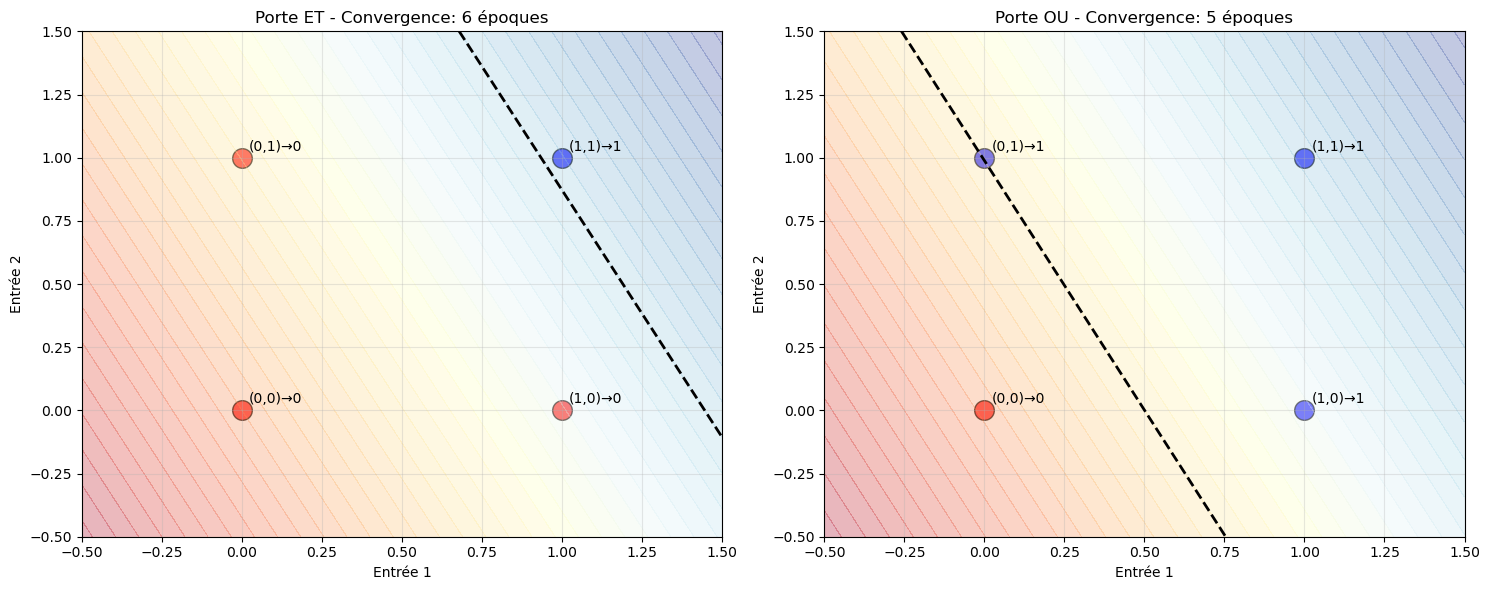

✅ Le perceptron peut résoudre ET et OU (linéairement séparables)
❌ Mais il ne peut PAS résoudre XOR (non-linéairement séparable)


In [6]:
def probleme_et_ou():
    """Test sur les portes logiques ET et OU"""
    
    # Données pour ET et OU
    X_et = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_et = np.array([0, 0, 0, 1])  # ET logique
    
    X_ou = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_ou = np.array([0, 1, 1, 1])  # OU logique
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for idx, (X, y, title) in enumerate([(X_et, y_et, 'Porte ET'), (X_ou, y_ou, 'Porte OU')]):
        # Entraînement
        perceptron = Perceptron(learning_rate=0.1, max_iter=100)
        perceptron.fit(X, y)
        
        # Visualisation
        ax = axes[idx]
        colors = ['red', 'blue']
        
        for i in range(2):
            mask = y == i
            ax.scatter(X[mask, 0], X[mask, 1], 
                      c=colors[i], s=200, alpha=0.7, edgecolors='black')
        
        # Annotations
        for i, (x, label) in enumerate(zip(X, y)):
            ax.annotate(f'({x[0]},{x[1]})→{label}', 
                       (x[0], x[1]), xytext=(5, 5), 
                       textcoords='offset points', fontsize=10)
        
        # Frontière de décision
        if perceptron.weights is not None:
            xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                                np.linspace(-0.5, 1.5, 100))
            mesh_points = np.c_[xx.ravel(), yy.ravel()]
            Z = perceptron.decision_function(mesh_points)
            Z = Z.reshape(xx.shape)
            
            ax.contour(xx, yy, Z, levels=[0], colors='black', linestyles='--', linewidths=2)
            ax.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap='RdYlBu')
        
        ax.set_xlabel('Entrée 1')
        ax.set_ylabel('Entrée 2')
        ax.set_title(f'{title} - Convergence: {len(perceptron.errors)} époques')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Le perceptron peut résoudre ET et OU (linéairement séparables)")
    print("❌ Mais il ne peut PAS résoudre XOR (non-linéairement séparable)")

probleme_et_ou()

## ⚠️ 6. Limitations du Perceptron

Le perceptron ne peut résoudre que des problèmes **linéairement séparables**.

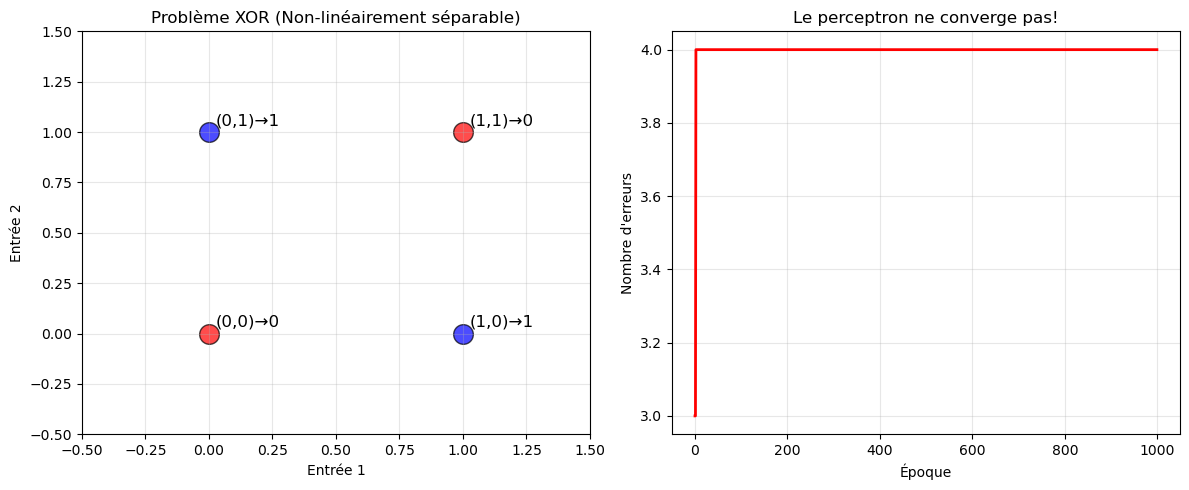

❌ Précision sur XOR: 25.00%
🔄 Erreurs après 1000 époques: 4

💡 Solution: Utiliser des réseaux multi-couches (MLP) !


In [7]:
def demo_limitation_xor():
    """Démonstration de la limitation avec XOR"""
    
    # Données XOR
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])  # XOR logique
    
    # Tentative d'entraînement
    perceptron = Perceptron(learning_rate=0.1, max_iter=1000)
    perceptron.fit(X_xor, y_xor)
    
    # Visualisation
    plt.figure(figsize=(12, 5))
    
    # Graphique 1: Données XOR
    plt.subplot(1, 2, 1)
    colors = ['red', 'blue']
    
    for i in range(2):
        mask = y_xor == i
        plt.scatter(X_xor[mask, 0], X_xor[mask, 1], 
                   c=colors[i], s=200, alpha=0.7, edgecolors='black')
    
    # Annotations
    for i, (x, label) in enumerate(zip(X_xor, y_xor)):
        plt.annotate(f'({x[0]},{x[1]})→{label}', 
                    (x[0], x[1]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=12)
    
    plt.xlabel('Entrée 1')
    plt.ylabel('Entrée 2')
    plt.title('Problème XOR (Non-linéairement séparable)')
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    
    # Graphique 2: Évolution des erreurs
    plt.subplot(1, 2, 2)
    plt.plot(perceptron.errors, 'r-', linewidth=2)
    plt.xlabel('Époque')
    plt.ylabel('Nombre d\'erreurs')
    plt.title('Le perceptron ne converge pas!')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    accuracy = np.mean(perceptron.predict(X_xor) == np.where(y_xor <= 0, -1, 1))
    print(f"❌ Précision sur XOR: {accuracy:.2%}")
    print(f"🔄 Erreurs après {len(perceptron.errors)} époques: {perceptron.errors[-1]}")
    print()
    print("💡 Solution: Utiliser des réseaux multi-couches (MLP) !")

demo_limitation_xor()

## 🎓 Résumé - Le Perceptron

### ✅ Avantages:
- Simple à comprendre et implémenter
- Garantie de convergence pour problèmes linéairement séparables
- Base historique du Deep Learning

### ❌ Limitations:
- Seulement problèmes linéairement séparables
- Une seule couche de calcul
- Pas de fonction d'activation non-linéaire

### 🚀 Prochaine étape:
**Partie 2**: Perceptrons Multi-Couches (MLPs) pour résoudre XOR et plus!

In [8]:
def quiz_perceptron():
    """Quiz sur le perceptron"""
    print("🎯 QUIZ - Le Perceptron")
    print("="*30)
    print()
    print("1. Le perceptron peut-il résoudre XOR?")
    print("   A) Oui, toujours")
    print("   B) Non, jamais") 
    print("   C) Seulement avec plus d'itérations")
    print()
    print("2. Que fait la règle d'apprentissage du perceptron?")
    print("   A) w = w + lr × erreur × x")
    print("   B) w = w + lr × target × x")
    print("   C) w = w + lr × (target - prediction) × x")
    print()
    print("3. Un problème linéairement séparable signifie:")
    print("   A) On peut tracer une ligne droite pour séparer les classes")
    print("   B) Les données sont sur une ligne")
    print("   C) Il faut une fonction linéaire")
    print()
    print("Réponses: 1-B, 2-C, 3-A")

quiz_perceptron()

🎯 QUIZ - Le Perceptron

1. Le perceptron peut-il résoudre XOR?
   A) Oui, toujours
   B) Non, jamais
   C) Seulement avec plus d'itérations

2. Que fait la règle d'apprentissage du perceptron?
   A) w = w + lr × erreur × x
   B) w = w + lr × target × x
   C) w = w + lr × (target - prediction) × x

3. Un problème linéairement séparable signifie:
   A) On peut tracer une ligne droite pour séparer les classes
   B) Les données sont sur une ligne
   C) Il faut une fonction linéaire

Réponses: 1-B, 2-C, 3-A
